In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/person1949_bacteria_4880.jpeg
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/.DS_Store
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA/per

In [ ]:
# Paths
train_dir = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_dir   = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_dir  = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [ ]:
# Defining paths for each class within each set.
# Training paths
import os
train_normal_dir = os.path.join(train_dir, 'NORMAL')
train_pneumonia_dir = os.path.join(train_dir, 'PNEUMONIA')

# Validation paths
val_normal_dir = os.path.join(val_dir, 'NORMAL')
val_pneumonia_dir = os.path.join(val_dir, 'PNEUMONIA')

# Test paths
test_normal_dir = os.path.join(test_dir, 'NORMAL')
test_pneumonia_dir = os.path.join(test_dir, 'PNEUMONIA')

In [ ]:
# number of images in each category.
num_train_normal = len(os.listdir(train_normal_dir))
num_train_pneumonia = len(os.listdir(train_pneumonia_dir))

num_val_normal = len(os.listdir(val_normal_dir))
num_val_pneumonia = len(os.listdir(val_pneumonia_dir))

num_test_normal = len(os.listdir(test_normal_dir))
num_test_pneumonia = len(os.listdir(test_pneumonia_dir))

total_train = num_train_normal + num_train_pneumonia
total_val = num_val_normal + num_val_pneumonia
total_test = num_test_normal + num_test_pneumonia

# Print the counts
print("Image Counts:")
print(f"Total Training Images: {total_train}")
print(f"  - Normal: {num_train_normal}")
print(f"  - Pneumonia: {num_train_pneumonia}")
print("-" * 20)
print(f"Total Validation Images: {total_val}")
print(f"  - Normal: {num_val_normal}")
print(f"  - Pneumonia: {num_val_pneumonia}")
print("-" * 20)
print(f"Total Testing Images: {total_test}")
print(f"  - Normal: {num_test_normal}")
print(f"  - Pneumonia: {num_test_pneumonia}")
print("-" * 20)

Image Counts:
Total Training Images: 5216
  - Normal: 1341
  - Pneumonia: 3875
--------------------
Total Validation Images: 16
  - Normal: 8
  - Pneumonia: 8
--------------------
Total Testing Images: 624
  - Normal: 234
  - Pneumonia: 390
--------------------


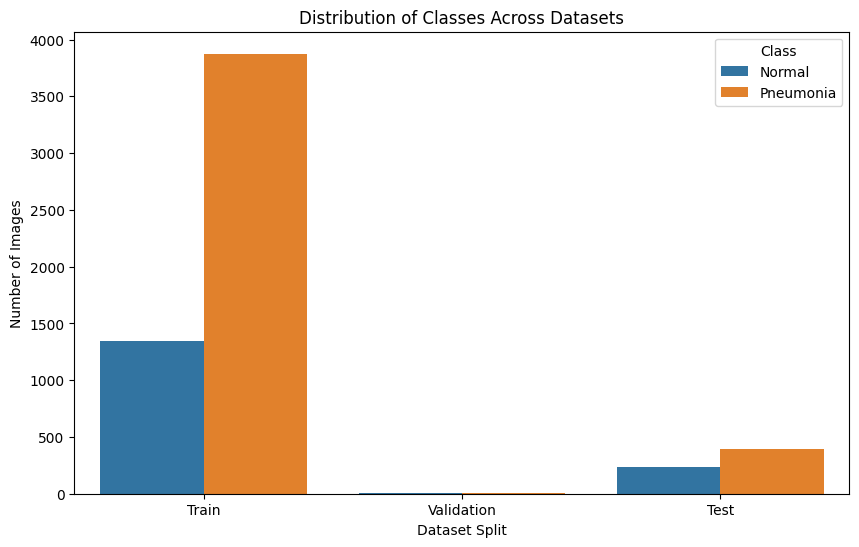

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
data = {
  'Set': ['Train', 'Train', 'Validation', 'Validation', 'Test', 'Test'],
  'Class': ['Normal', 'Pneumonia', 'Normal', 'Pneumonia', 'Normal', 'Pneumonia'],
  'Count': [num_train_normal, num_train_pneumonia, num_val_normal, num_val_pneumonia, num_test_normal, num_test_pneumonia]
}
df_counts = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Set', y='Count', hue='Class', data=df_counts)
plt.title('Distribution of Classes Across Datasets')
plt.ylabel('Number of Images')
plt.xlabel('Dataset Split')
plt.show()

Sample 'Normal' Images


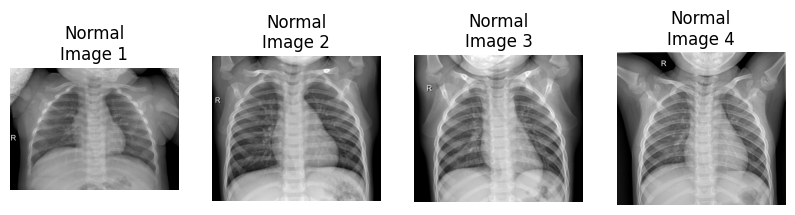


Sample 'Pneumonia' Images


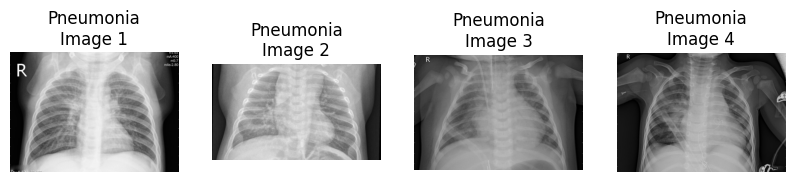

In [ ]:
import cv2
import random

def display_samples(directory, class_name, num_samples=4):
  """Displays a grid of random sample images from a given directory."""
  plt.figure(figsize=(10, 5))
  image_files = os.listdir(directory)
  random_samples = random.sample(image_files, num_samples)

  for i, file in enumerate(random_samples):
    image_path = os.path.join(directory, file)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(1, num_samples, i + 1)
    plt.imshow(image)
    plt.title(f"{class_name}\nImage {i+1}")
    plt.axis('off')
  plt.show()

# Display samples for Normal class from the training set.
print("Sample 'Normal' Images")
display_samples(train_normal_dir, 'Normal')

# Display samples for Pneumonia class from the training set
print("\nSample 'Pneumonia' Images")
display_samples(train_pneumonia_dir, 'Pneumonia')

Significant Class Imbalance: The bar chart and the raw counts clearly show a major imbalance in our training dataset. There are 3,875 images of Pneumonia but only 1,341 Normal images. This means the Pneumonia class is over-represented by a ratio of nearly 3:1.

Validation Set Size: The validation set is extremely small constaining only 16 iamges (8 per class).

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image size (common for transfer learning models like VGG/ResNet)
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Train Data Generator (with augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow from directories
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


2025-11-02 18:27:52.874412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762108073.066057      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762108073.119997      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze pretrained layers

model = Sequential([
    base_model,
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # binary classification
])


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

In [ ]:
def lr_schedule(epoch, lr):
    # Example: Decrease learning rate by 10% every 5 epochs
    if epoch % 5 == 0 and epoch > 0:
        lr *= 0.9
    return float(lr)  # Ensure the return value is a float

# Create LearningRateScheduler
# Keras callback that applies lr_schedule function every epoch
learning_rate_scheduler = LearningRateScheduler(lr_schedule)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

In [ ]:
history = model.fit(
    train_data,
    epochs=60,
    validation_data=val_data,
    callbacks=[early_stopping, learning_rate_scheduler]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1762108202.384143     124 service.cc:148] XLA service 0x78dcb1267170 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1762108202.385029     124 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1762108202.385050     124 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1762108203.899419     124 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/163 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - accuracy: 0.4297 - loss: 1.1446 

I0000 00:00:1762108208.802825     124 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


163/163 ━━━━━━━━━━━━━━━━━━━━ 138s 752ms/step - accuracy: 0.7110 - loss: 0.7275 - val_accuracy: 0.5625 - val_loss: 0.7474 - learning_rate: 1.0000e-04
Epoch 2/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 88s 542ms/step - accuracy: 0.7973 - loss: 0.4308 - val_accuracy: 0.5625 - val_loss: 1.1686 - learning_rate: 1.0000e-04
Epoch 3/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 552ms/step - accuracy: 0.8283 - loss: 0.3698 - val_accuracy: 0.5625 - val_loss: 0.8872 - learning_rate: 1.0000e-04
Epoch 4/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 546ms/step - accuracy: 0.8365 - loss: 0.3554 - val_accuracy: 0.6250 - val_loss: 0.7458 - learning_rate: 1.0000e-04
Epoch 5/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 546ms/step - accuracy: 0.8444 - loss: 0.3402 - val_accuracy: 0.6250 - val_loss: 0.7148 - learning_rate: 1.0000e-04
Epoch 6/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 89s 547ms/step - accuracy: 0.8550 - loss: 0.3107 - val_accuracy: 0.6250 - val_loss: 0.9732 - learning_rate: 9.0000e-05
Epoch 7/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 87s 536ms/step -

In [ ]:
# Evaluate on validation set
results = model.evaluate(val_data)
print(f"Validation Loss: {results[0]:.4f}, Validation Accuracy: {results[1]:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7500 - loss: 0.5664
Validation Loss: 0.5664, Validation Accuracy: 0.7500


In [ ]:
# Evaluate on test set
test_results = model.evaluate(test_data)
print(f"Test Loss: {test_results[0]:.4f}, Test Accuracy: {test_results[1]:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 0.8560 - loss: 0.3711
Test Loss: 0.3293, Test Accuracy: 0.8654


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 428ms/step
              precision    recall  f1-score   support

      NORMAL       0.82      0.83      0.82       234
   PNEUMONIA       0.90      0.89      0.89       390

    accuracy                           0.87       624
   macro avg       0.86      0.86      0.86       624
weighted avg       0.87      0.87      0.87       624



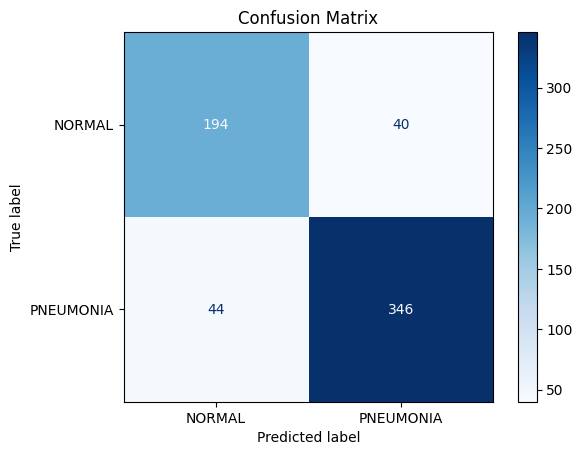

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Get true labels
y_true = test_data.classes

# 2️⃣ Get model predictions
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype("int32")  # binary classification

# 3️⃣ Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

# 4️⃣ Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_data.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

# Load VGG16 without top layers (pretrained on ImageNet)
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the convolutional base
base_model.trainable = False

# Build your model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # change to Dense(num_classes, 'softmax') for multi-class
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy',   # use 'categorical_crossentropy' for multi-class
              metrics=['accuracy'])

model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,137,729 (80.63 MB)

 Trainable params: 6,423,041 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(
    train_data,
    epochs=60,
    validation_data=val_data,
    callbacks=[early_stopping, learning_rate_scheduler]
)


Epoch 1/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 116s 611ms/step - accuracy: 0.8580 - loss: 0.3080 - val_accuracy: 0.7500 - val_loss: 0.3518 - learning_rate: 1.0000e-04
Epoch 2/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 560ms/step - accuracy: 0.9373 - loss: 0.1576 - val_accuracy: 0.8125 - val_loss: 0.3100 - learning_rate: 1.0000e-04
Epoch 3/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 560ms/step - accuracy: 0.9499 - loss: 0.1276 - val_accuracy: 0.8125 - val_loss: 0.2924 - learning_rate: 1.0000e-04
Epoch 4/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 568ms/step - accuracy: 0.9502 - loss: 0.1275 - val_accuracy: 0.8125 - val_loss: 0.3345 - learning_rate: 1.0000e-04
Epoch 5/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 93s 568ms/step - accuracy: 0.9565 - loss: 0.1197 - val_accuracy: 0.8125 - val_loss: 0.3085 - learning_rate: 1.0000e-04
Epoch 6/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 561ms/step - accuracy: 0.9664 - loss: 0.0985 - val_accuracy: 0.6875 - val_loss: 0.5215 - learning_rate: 9.0000e-05
Epoch 7/60
163/163 ━━━━━━━━━━━━━━━━━━━━ 91s 5

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step
              precision    recall  f1-score   support

      NORMAL       0.90      0.90      0.90       234
   PNEUMONIA       0.94      0.94      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.92      0.92       624
weighted avg       0.92      0.92      0.92       624



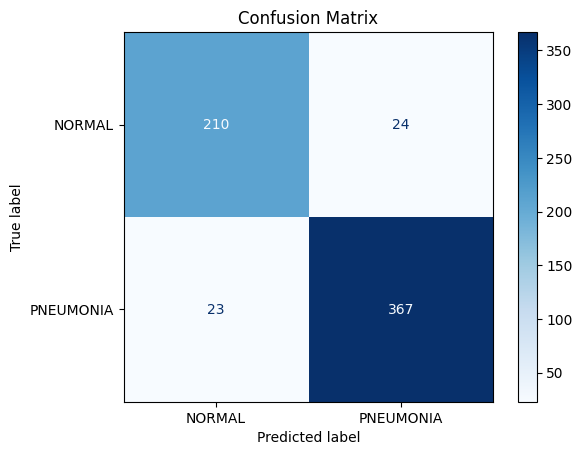

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Get true labels
y_true = test_data.classes

# 2️⃣ Get model predictions
y_pred_prob = model.predict(test_data)
y_pred = (y_pred_prob > 0.5).astype("int32")  # binary classification

# 3️⃣ Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_data.class_indices.keys())
))

# 4️⃣ Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_data.class_indices.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
from tensorflow.keras.models import Model

def scorecam(model, img_array, layer_name, class_index=None, upsample_size=(224, 224)):
    # Get the target layer
    target_layer = model.get_layer(layer_name)
    sub_model = Model(inputs=model.inputs, outputs=[target_layer.output, model.output])

    # Forward pass
    conv_outputs, predictions = sub_model(img_array)
    conv_outputs = conv_outputs[0]

    if class_index is None:
        class_index = np.argmax(predictions[0])

    # Resize and normalize each activation map, feed it to model to get score
    score_weighted_maps = []
    for i in range(conv_outputs.shape[-1]):
        activation_map = conv_outputs[..., i]
        activation_map = cv2.resize(activation_map.numpy(), upsample_size)
        activation_map = np.maximum(activation_map, 0)
        if np.max(activation_map) != 0:
            activation_map /= np.max(activation_map)

        # Mask input image with normalized activation map
        masked_input = img_array.copy()
        masked_input[0] = masked_input[0] * activation_map[..., np.newaxis]

        # Forward pass again to get the score for this masked input
        score = model(masked_input)[0, class_index].numpy()
        score_weighted_maps.append(score * activation_map)

    # Combine all weighted maps
    cam = np.mean(score_weighted_maps, axis=0)
    cam = np.maximum(cam, 0)
    cam = cam / np.max(cam)

    return cv2.resize(cam, upsample_size)


553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_556']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


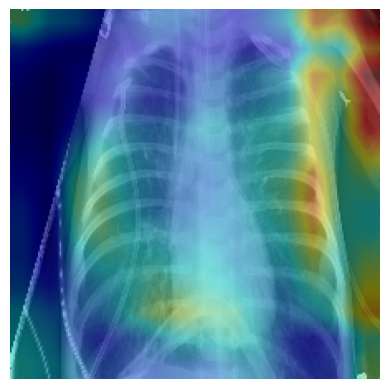

In [ ]:
# Example for VGG16
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load model
model = VGG16(weights='imagenet')
img_path = '/kaggle/input/chest-xray-pneumonia/chest_xray/test/PNEUMONIA/person109_bacteria_522.jpeg'  # change this
img = image.load_img(img_path, target_size=(224, 224))
img_array = np.expand_dims(image.img_to_array(img), axis=0)
img_array = preprocess_input(img_array)

# Apply Score-CAM
heatmap = scorecam(model, img_array, layer_name='block5_conv3')

# Overlay heatmap
def overlay_heatmap(heatmap, original_img, alpha=0.4, colormap=cv2.COLORMAP_JET):
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, colormap)
    output = cv2.addWeighted(original_img, 1 - alpha, heatmap, alpha, 0)
    return output

original_img = cv2.imread(img_path)
original_img = cv2.resize(original_img, (224, 224))
output_img = overlay_heatmap(heatmap, original_img)

plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
